In [1]:

import pandas as pd
import numpy as np
import sqlite3

# Load your existing Day 7 stock prices
prices = pd.read_csv(
    "five_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]

prices = prices[tickers].sort_index().dropna()

print("Trading days:", len(prices))
print("Stocks:", list(prices.columns))

display(prices.head())

Trading days: 250
Stocks: ['AAPL', 'MSFT', 'JPM', 'GS', 'BLK']


,AAPL,MSFT,JPM,GS,BLK
Date,,,,,
2025-09-23,253.493591,505.074463,306.869354,790.766968,1108.070068
2025-09-24,251.381409,505.986908,307.536621,777.144836,1104.378906
2025-09-25,255.924637,502.892334,307.566071,779.429932,1123.284790
2025-09-26,254.519806,507.286194,310.127045,787.030518,1132.253052
2025-09-29,253.493591,510.400513,309.764008,788.609436,1150.963501


In [2]:

# STEP 2: Create a hedge fund market database

import sqlite3
import pandas as pd

# Convert the stock prices into database format
market_data = (
    prices
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="ticker",
        value_name="close_price"
    )
)

market_data["Date"] = pd.to_datetime(
    market_data["Date"]
).dt.strftime("%Y-%m-%d")

market_data = market_data.rename(
    columns={"Date": "date"}
)

# Create the SQLite database
conn = sqlite3.connect("hedge_fund.db")

# Save stock prices in a database table
market_data.to_sql(
    "daily_prices",
    conn,
    if_exists="replace",
    index=False
)

# Verify the database
result = pd.read_sql_query(
    """
    SELECT
        ticker,
        COUNT(*) AS trading_days,
        ROUND(MIN(close_price), 2) AS lowest_price,
        ROUND(MAX(close_price), 2) AS highest_price
    FROM daily_prices
    GROUP BY ticker
    ORDER BY ticker
    """,
    conn
)

display(result)

,ticker,trading_days,lowest_price,highest_price
0,AAPL,250,244.37,339.79
1,BLK,250,913.04,1177.43
2,GS,250,730.24,1146.46
3,JPM,250,280.14,365.18
4,MSFT,250,352.17,537.65


In [3]:

# STEP 3: Calculate daily returns using SQL

query = """
WITH price_history AS (
    SELECT
        date,
        ticker,
        close_price,
        LAG(close_price) OVER (
            PARTITION BY ticker
            ORDER BY date
        ) AS previous_close
    FROM daily_prices
)
SELECT
    date,
    ticker,
    ROUND(close_price, 2) AS close_price,
    ROUND(
        (close_price / previous_close - 1) * 100,
        4
    ) AS daily_return_pct
FROM price_history
WHERE previous_close IS NOT NULL
ORDER BY date, ticker
"""

daily_returns = pd.read_sql_query(query, conn)

print("Daily return records:", len(daily_returns))
display(daily_returns.head(10))

Daily return records: 1245


,date,ticker,close_price,daily_return_pct
0,2025-09-24,AAPL,251.38,-0.8332
1,2025-09-24,BLK,1104.38,-0.3331
2,2025-09-24,GS,777.14,-1.7226
3,2025-09-24,JPM,307.54,0.2174
4,2025-09-24,MSFT,505.99,0.1807
5,2025-09-25,AAPL,255.92,1.8073
6,2025-09-25,BLK,1123.28,1.7119
7,2025-09-25,GS,779.43,0.2940
8,2025-09-25,JPM,307.57,0.0096
9,2025-09-25,MSFT,502.89,-0.6116


In [4]:

# STEP 4: Stock risk and return analysis

import numpy as np
import pandas as pd

# Convert percentage returns to decimal returns
daily_returns["daily_return"] = (
    daily_returns["daily_return_pct"] / 100
)

# Group returns by stock
stock_stats = daily_returns.groupby("ticker")["daily_return"].agg(
    average_daily_return="mean",
    daily_volatility="std",
    observations="count"
)

# Annualize the statistics
stock_stats["annualized_return_pct"] = (
    stock_stats["average_daily_return"] * 252 * 100
)

stock_stats["annualized_volatility_pct"] = (
    stock_stats["daily_volatility"] * np.sqrt(252) * 100
)

# Display the risk and return report
report = stock_stats[
    ["observations",
     "annualized_return_pct",
     "annualized_volatility_pct"]
].round(2)

display(report)

,observations,annualized_return_pct,annualized_volatility_pct
ticker,,,
AAPL,249,32.45,24.59
BLK,249,2.13,27.51
GS,249,24.73,32.22
JPM,249,16.37,22.22
MSFT,249,4.53,32.66


In [5]:

# STEP 5: Simulated $1 million hedge fund portfolio

import numpy as np
import pandas as pd

initial_capital = 1_000_000

weights = pd.Series({
    "AAPL": 0.25,
    "MSFT": 0.25,
    "JPM": 0.20,
    "GS": 0.15,
    "BLK": 0.15
})

assert np.isclose(weights.sum(), 1.0)

# Calculate daily returns using unrounded prices
returns = prices[weights.index].pct_change().dropna()

# Assume portfolio weights are rebalanced daily
portfolio_returns = returns @ weights

# Simulate portfolio growth
portfolio_value = (
    initial_capital * (1 + portfolio_returns).cumprod()
)

# Calculate portfolio statistics
total_return = portfolio_value.iloc[-1] / initial_capital - 1
annualized_volatility = portfolio_returns.std() * np.sqrt(252)

running_peak = portfolio_value.cummax()
drawdown = portfolio_value / running_peak - 1

summary = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Final Portfolio Value",
        "Cumulative Return",
        "Annualized Volatility",
        "Maximum Drawdown"
    ],
    "Value": [
        f"${initial_capital:,.2f}",
        f"${portfolio_value.iloc[-1]:,.2f}",
        f"{total_return:.2%}",
        f"{annualized_volatility:.2%}",
        f"{drawdown.min():.2%}"
    ]
})

display(summary)

,Metric,Value
0,Initial Capital,"$1,000,000.00"
1,Final Portfolio Value,"$1,159,726.71"
2,Cumulative Return,15.97%
3,Annualized Volatility,17.64%
4,Maximum Drawdown,-15.23%


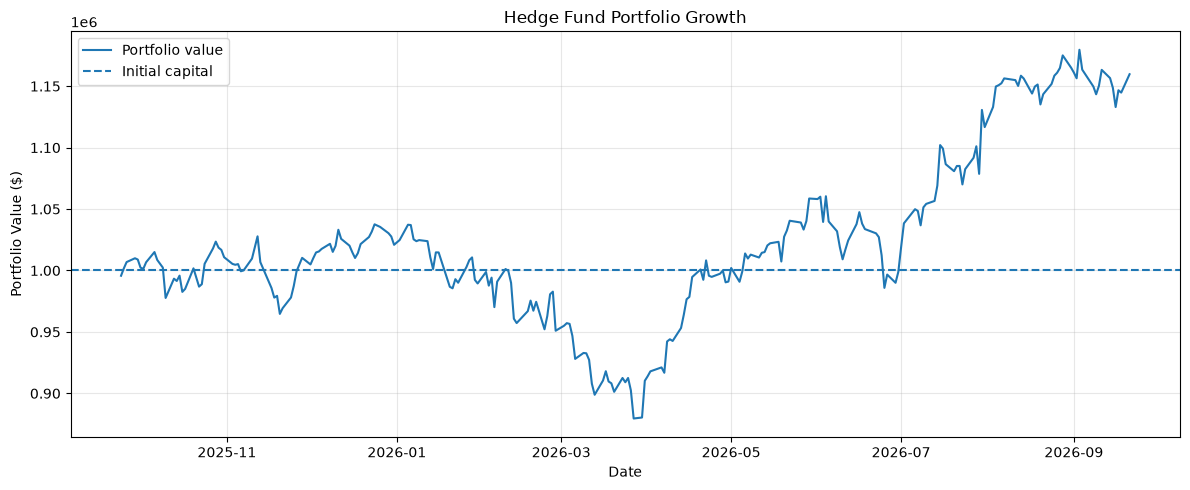

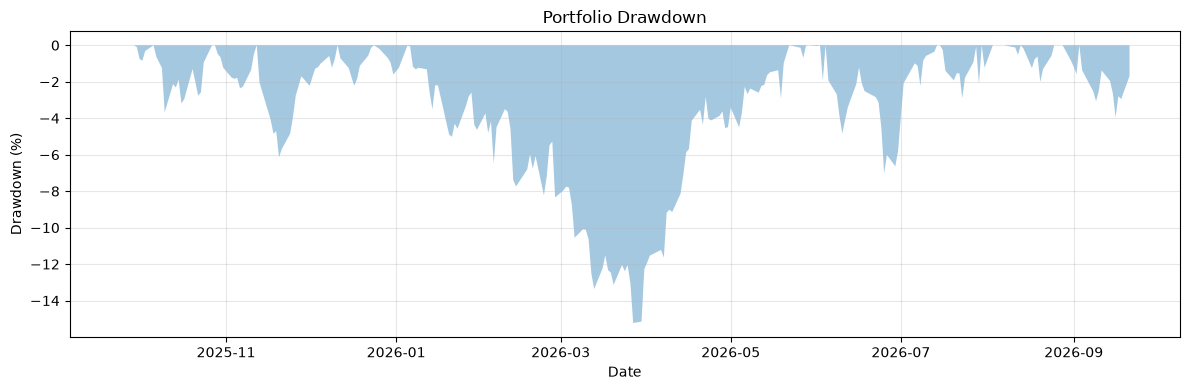

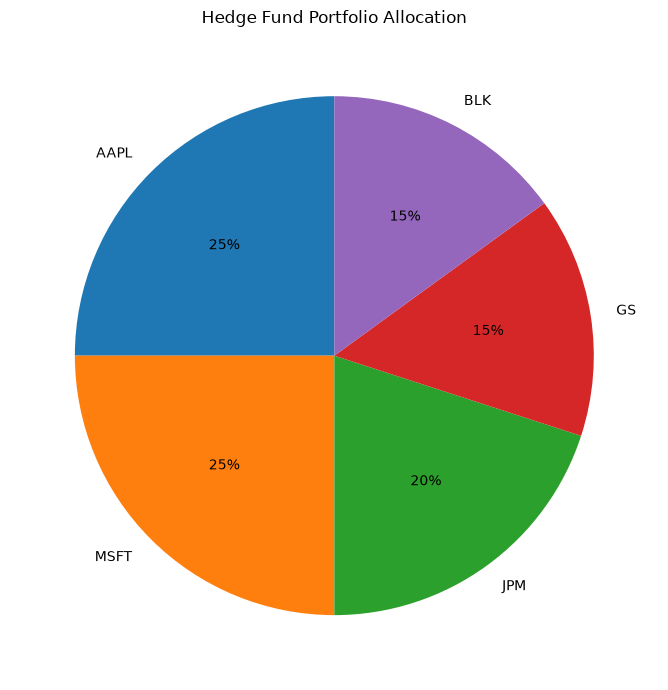

In [6]:

# STEP 6: Hedge fund portfolio dashboard

import matplotlib.pyplot as plt

# Chart 1: Portfolio growth
plt.figure(figsize=(12, 5))
plt.plot(
    portfolio_value.index,
    portfolio_value.values,
    label="Portfolio value"
)
plt.axhline(
    initial_capital,
    linestyle="--",
    label="Initial capital"
)
plt.title("Hedge Fund Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chart 2: Portfolio drawdown
plt.figure(figsize=(12, 4))
plt.fill_between(
    drawdown.index,
    drawdown.values * 100,
    0,
    alpha=0.4
)
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chart 3: Portfolio allocation
plt.figure(figsize=(7, 7))
plt.pie(
    weights.values,
    labels=weights.index,
    autopct="%1.0f%%",
    startangle=90
)
plt.title("Hedge Fund Portfolio Allocation")
plt.tight_layout()
plt.show()

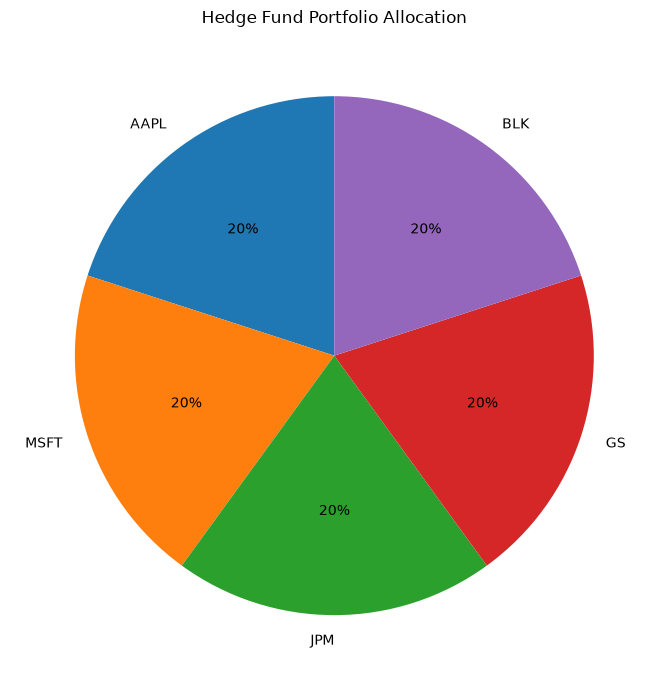

In [7]:

# Chart 3: Portfolio allocation
tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]
allocation = [20, 20, 20, 20, 20]

plt.figure(figsize=(7, 7))
plt.pie(
    allocation,
    labels=tickers,
    autopct="%1.0f%%",
    startangle=90
)
plt.title("Hedge Fund Portfolio Allocation")
plt.tight_layout()
plt.show()

In [8]:

import numpy as np
import pandas as pd

# Use the portfolio's daily returns calculated earlier
# Change this name if your existing variable is different
portfolio_daily_returns = portfolio_returns.dropna()

# Assumed annual risk-free rate (4%)
risk_free_rate = 0.04

annualized_return = (
    (1 + portfolio_daily_returns).prod()
    ** (252 / len(portfolio_daily_returns))
    - 1
)

annualized_volatility = (
    portfolio_daily_returns.std() * np.sqrt(252)
)

sharpe_ratio = (
    (annualized_return - risk_free_rate)
    / annualized_volatility
)

print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Annualized Return: 16.18%
Annualized Volatility: 17.64%
Sharpe Ratio: 0.69


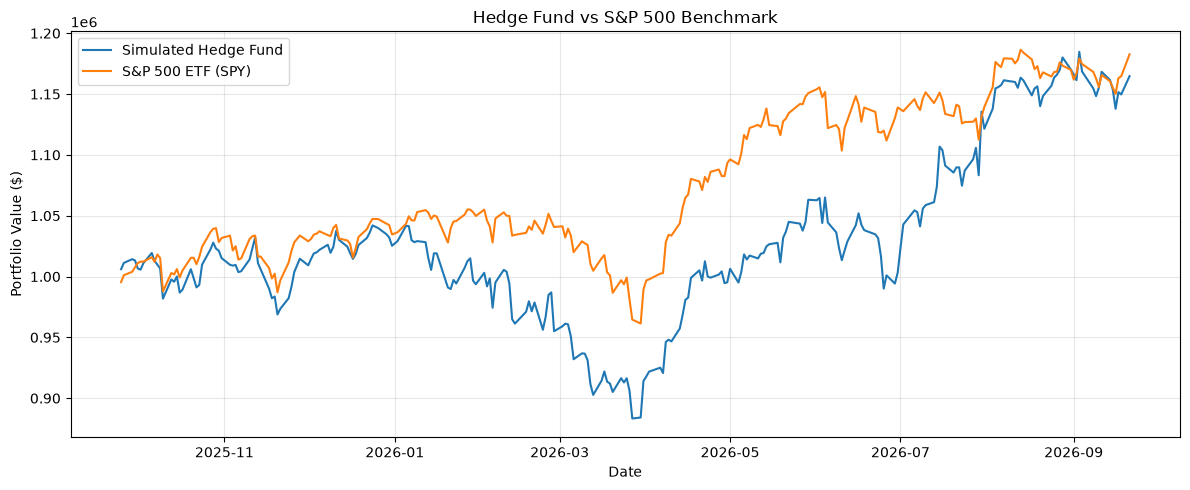

,Total Return,Annualized Volatility
Hedge Fund,16.47%,17.67%
S&P 500 ETF,18.26%,13.04%


In [9]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Match the benchmark dates to your portfolio
start_date = portfolio_daily_returns.index.min()
end_date = portfolio_daily_returns.index.max() + pd.Timedelta(days=1)

sp500 = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

# Handle possible yfinance multi-index columns
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

benchmark_returns = sp500["Close"].pct_change().dropna()

# Align portfolio and benchmark on identical trading days
comparison = pd.concat(
    [
        portfolio_daily_returns.rename("Hedge Fund"),
        benchmark_returns.rename("S&P 500 ETF")
    ],
    axis=1
).dropna()

# Normalize both investments to $1,000,000
growth = (1 + comparison).cumprod() * 1_000_000

plt.figure(figsize=(12, 5))
plt.plot(growth.index, growth["Hedge Fund"],
         label="Simulated Hedge Fund")
plt.plot(growth.index, growth["S&P 500 ETF"],
         label="S&P 500 ETF (SPY)")
plt.title("Hedge Fund vs S&P 500 Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate comparable performance statistics
results = pd.DataFrame({
    "Total Return": (1 + comparison).prod() - 1,
    "Annualized Volatility":
        comparison.std() * np.sqrt(252)
})

display(results.style.format("{:.2%}"))

In [10]:

import numpy as np
import pandas as pd

fund = comparison["Hedge Fund"]
benchmark = comparison["S&P 500 ETF"]

# Assumed annual risk-free rate
rf_annual = 0.04
rf_daily = (1 + rf_annual) ** (1 / 252) - 1

# Beta measures sensitivity to the benchmark
beta = fund.cov(benchmark) / benchmark.var()

# Annualized geometric returns
fund_annual = (1 + fund).prod() ** (252 / len(fund)) - 1
benchmark_annual = (
    (1 + benchmark).prod()
    ** (252 / len(benchmark)) - 1
)

# Jensen's alpha using annualized returns
alpha = (
    fund_annual
    - (rf_annual + beta * (benchmark_annual - rf_annual))
)

# Tracking error and information ratio
active_returns = fund - benchmark
tracking_error = active_returns.std() * np.sqrt(252)

# Annualized geometric relative return
relative_growth = (1 + fund) / (1 + benchmark)
annualized_relative_return = (
    relative_growth.prod() ** (252 / len(relative_growth)) - 1
)

information_ratio = (
    annualized_relative_return / tracking_error
    if tracking_error > 0 else np.nan
)

report = pd.DataFrame({
    "Metric": [
        "Beta",
        "Jensen's Alpha",
        "Tracking Error",
        "Annualized Relative Return",
        "Information Ratio"
    ],
    "Value": [
        f"{beta:.2f}",
        f"{alpha:.2%}",
        f"{tracking_error:.2%}",
        f"{annualized_relative_return:.2%}",
        f"{information_ratio:.2f}"
    ]
})

display(report)

,Metric,Value
0,Beta,0.98
1,Jensen's Alpha,-1.51%
2,Tracking Error,12.23%
3,Annualized Relative Return,-1.54%
4,Information Ratio,-0.13
